In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
import numpy as np
import pennylane as qml
import matplotlib.pyplot as plt
from PIL import Image
import pywt.data

from src.encoding import QuantumImageEncoder
from src.hqwt_1d import qhaar_1d, qhaar_1d_inverse
from src.hqwt_2d import qhaar_2d, qhaar_2d_inverse
from src.d4qwt_1d import Dp_2n, Dp_2n_inverse, F_2n, F_2n_inverse
from src.d4qwt_2d import qd4_2d, qd4_2d_inverse

### Encoding test

In [3]:
matrix = np.random.rand(512, 512)
encode, n_qubits, spatial = QuantumImageEncoder.encode_grayscale(matrix)
state = encode()
expected = matrix.flatten() / np.linalg.norm(matrix.flatten())
print("Encoding correct:", np.allclose(state, expected))

Encoding correct: True


In [4]:
img = Image.open("../results/IISc.png")
img_gray = img.convert("L")
matrix = np.array(img_gray, dtype=float)

print("Shape:", matrix.shape)

circuit, n_qubits, spatial = QuantumImageEncoder.encode_grayscale(matrix)

print(qml.draw(circuit)())

Shape: (512, 512)
 0: ─╭|Ψ⟩─┤  State
 1: ─├|Ψ⟩─┤  State
 2: ─├|Ψ⟩─┤  State
 3: ─├|Ψ⟩─┤  State
 4: ─├|Ψ⟩─┤  State
 5: ─├|Ψ⟩─┤  State
 6: ─├|Ψ⟩─┤  State
 7: ─├|Ψ⟩─┤  State
 8: ─├|Ψ⟩─┤  State
 9: ─├|Ψ⟩─┤  State
10: ─├|Ψ⟩─┤  State
11: ─├|Ψ⟩─┤  State
12: ─├|Ψ⟩─┤  State
13: ─├|Ψ⟩─┤  State
14: ─├|Ψ⟩─┤  State
15: ─├|Ψ⟩─┤  State
16: ─├|Ψ⟩─┤  State
17: ─╰|Ψ⟩─┤  State


## Test 1D Quantum Haar Wavelet Transform 

In [5]:
matrix = np.random.rand(8, 8)

encode, n_qubits, spatial = QuantumImageEncoder.encode_grayscale(matrix)

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def circuit():
    qml.AmplitudeEmbedding(
        matrix.flatten() / np.linalg.norm(matrix.flatten()),
        wires=range(n_qubits),
        normalize=False
    )
    qhaar_1d(range(n_qubits))
    qhaar_1d_inverse(range(n_qubits))
    return qml.state()

original = encode()
reconstructed = circuit()

print("Haar 1D correct:", np.allclose(original, reconstructed))

Haar 1D correct: True


## Test 2D Quantum Haar Wavelet Transform 

In [6]:
@qml.qnode(dev)
def circuit():
    qml.AmplitudeEmbedding(
        matrix.flatten() / np.linalg.norm(matrix.flatten()),
        wires=range(n_qubits),
        normalize=False
    )
    qhaar_2d(range(n_qubits), spatial)
    qhaar_2d_inverse(range(n_qubits), spatial)
    return qml.state()
reconstructed = circuit()
print("Haar 2D correct:", np.allclose(original, reconstructed))

Haar 2D correct: True


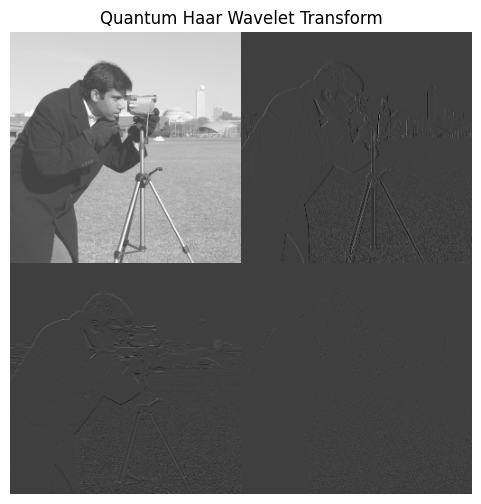

In [7]:
img = pywt.data.camera()
matrix = np.array(img, dtype=float)

encode, n_qubits, spatial = QuantumImageEncoder.encode_grayscale(matrix)

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def circuit():
    qml.AmplitudeEmbedding(
        matrix.flatten() / np.linalg.norm(matrix.flatten()),
        wires=range(n_qubits),
        normalize=False
    )
    qhaar_2d(range(n_qubits), spatial)
    return qml.state()

state = circuit()

norm = np.linalg.norm(matrix.flatten())
coeffs = np.real(state) * norm

transformed_image = coeffs.reshape(matrix.shape)

plt.figure(figsize=(6,6))
plt.imshow(transformed_image, cmap='gray')
plt.title("Quantum Haar Wavelet Transform")
plt.axis('off')
plt.show()

## Test 1D Daubechies 4 (D4) Quantum Wavelet Transform 

In [8]:
dev = qml.device("default.qubit", wires=[0,1,2,3])

@qml.qnode(dev)
def test():
    wires = [0,1,2,3]
    Dp_2n(wires)
    Dp_2n_inverse(wires)
    return qml.state()

state = test()
expected = np.array([1] + [0]*15)

print("Dp operator correct:", np.allclose(state, expected))

Dp operator correct: True


## Test F₂ⁿ (D4 QWT 1D test)

In [9]:
n = 4
dim = 2**n

vector = np.random.rand(dim)
vector = vector / np.linalg.norm(vector)

dev = qml.device("default.qubit", wires=n)

@qml.qnode(dev)
def test():
    qml.AmplitudeEmbedding(vector, wires=range(n), normalize=False)
    F_2n(range(n))
    F_2n_inverse(range(n))
    return qml.state()

reconstructed = test()

print("D4 1D correct:", np.allclose(vector, reconstructed))

D4 1D correct: True


## Test 2D Daubechies 4 (D4) Quantum Wavelet Transform 

In [10]:
matrix = np.random.rand(512,512)

encode, n_qubits, spatial = QuantumImageEncoder.encode_grayscale(matrix)

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def test():
    qml.AmplitudeEmbedding(
        matrix.flatten()/np.linalg.norm(matrix.flatten()),
        wires=range(n_qubits),
        normalize=False
    )
    qd4_2d(range(n_qubits), spatial)
    qd4_2d_inverse(range(n_qubits), spatial)
    return qml.state()

original = encode()
reconstructed = test()

print("D4 2D correct:", np.allclose(original, reconstructed))

D4 2D correct: True


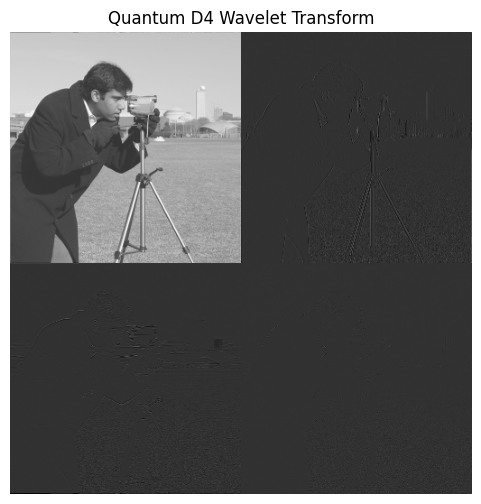

In [11]:
img = pywt.data.camera()
matrix = np.array(img, dtype=float)

encode, n_qubits, spatial = QuantumImageEncoder.encode_grayscale(matrix)

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def circuit():
    qml.AmplitudeEmbedding(
        matrix.flatten()/np.linalg.norm(matrix.flatten()),
        wires=range(n_qubits),
        normalize=False
    )
    qd4_2d(range(n_qubits), spatial)
    return qml.state()

state = circuit()

norm = np.linalg.norm(matrix.flatten())
coeffs = np.real(state) * norm

transformed_image = coeffs.reshape(matrix.shape)

plt.figure(figsize=(6,6))
plt.imshow(transformed_image, cmap='gray')
plt.title("Quantum D4 Wavelet Transform")
plt.axis('off')
plt.show()

## Test multilevel Haar 1D and 2D QWT

In [12]:
from src.multilevel_qwt import multilevel_haar_1d

n = 4
dim = 2**n

vector = np.random.rand(dim)
vector /= np.linalg.norm(vector)

dev = qml.device("default.qubit", wires=n)

@qml.qnode(dev)
def circuit():
    qml.AmplitudeEmbedding(vector, wires=range(n), normalize=False)
    multilevel_haar_1d(range(n), levels=2)
    return qml.state()

state = circuit()
print("Multilevel Haar 1D done")

Multilevel Haar 1D done


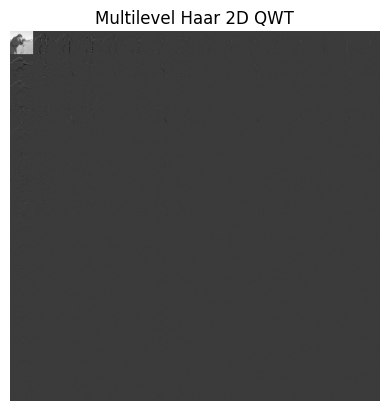

In [13]:
from src.multilevel_qwt import multilevel_haar_2d

img = pywt.data.camera()
matrix = np.array(img, dtype=float)

encode, n_qubits, spatial = QuantumImageEncoder.encode_grayscale(matrix)

dev = qml.device("default.qubit", wires=n_qubits)
@qml.qnode(dev)
def circuit():
    qml.AmplitudeEmbedding(
        matrix.flatten()/np.linalg.norm(matrix.flatten()),
        wires=range(n_qubits),
        normalize=False
    )
    multilevel_haar_2d(range(n_qubits), spatial, levels=4)
    return qml.state()

state = circuit()

norm = np.linalg.norm(matrix.flatten())
coeffs = np.real(state) * norm

img_out = coeffs.reshape(matrix.shape)

plt.imshow(img_out, cmap='gray')
plt.title("Multilevel Haar 2D QWT")
plt.axis('off')
plt.show()

Reconstruction is correct?: True


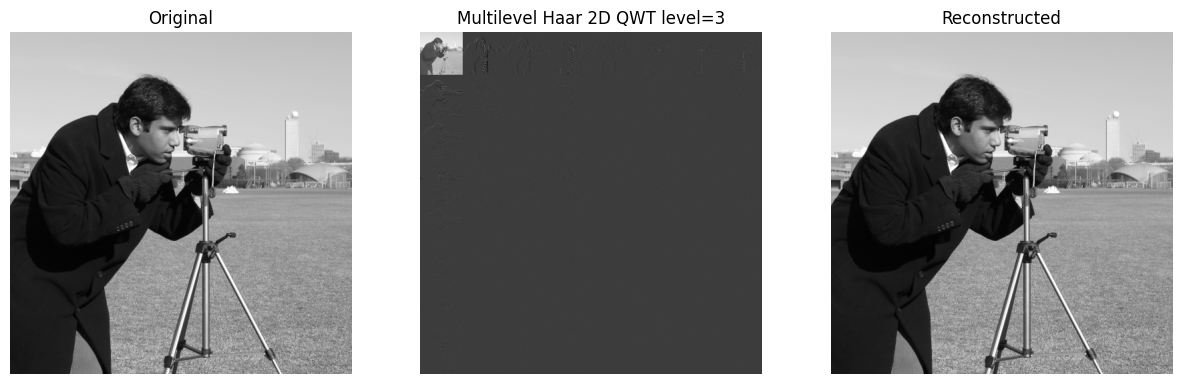

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml
import pywt.data
from src.encoding import QuantumImageEncoder
from src.multilevel_qwt import (multilevel_haar_2d, multilevel_haar_2d_inverse)

# Load image
img = pywt.data.camera()
matrix = np.array(img, dtype=float)
encode, n_qubits, spatial = QuantumImageEncoder.encode_grayscale(matrix)

dev = qml.device("default.qubit", wires=n_qubits)
@qml.qnode(dev)
def forward_circuit():
    qml.AmplitudeEmbedding(
        matrix.flatten()/np.linalg.norm(matrix.flatten()),
        wires=range(n_qubits),
        normalize=False
    )
    multilevel_haar_2d(range(n_qubits), spatial, levels=3)
    return qml.state()

@qml.qnode(dev)
def reconstruction_circuit():
    qml.AmplitudeEmbedding(
        matrix.flatten()/np.linalg.norm(matrix.flatten()),
        wires=range(n_qubits),
        normalize=False
    )
    multilevel_haar_2d(range(n_qubits), spatial, levels=3)
    multilevel_haar_2d_inverse(range(n_qubits), spatial, levels=3)
    return qml.state()

transformed = forward_circuit()
reconstructed = reconstruction_circuit()


# Recover scaling
norm = np.linalg.norm(matrix.flatten())
transformed_img = np.real(transformed) * norm
reconstructed_img = np.real(reconstructed) * norm
transformed_img = transformed_img.reshape(matrix.shape)
reconstructed_img = reconstructed_img.reshape(matrix.shape)
original = matrix.flatten()
reconstructed_vec = reconstructed_img.flatten()
print("Reconstruction is correct?:", np.allclose(original, reconstructed_vec, atol=1e-5))

############### Visualization of original, transformed, and reconstructed images #################

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(matrix, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(transformed_img, cmap='gray')
plt.title("Multilevel Haar 2D QWT level=3")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(reconstructed_img, cmap='gray')
plt.title("Reconstructed")
plt.axis('off')

plt.show()

## Test multilevel D4-- 1D and 2D QWT

In [15]:
from src.multilevel_qwt import multilevel_d4_1d

n = 4
dim = 2**n

vector = np.random.rand(dim)
vector /= np.linalg.norm(vector)

dev = qml.device("default.qubit", wires=n)

@qml.qnode(dev)
def circuit():
    qml.AmplitudeEmbedding(vector, wires=range(n), normalize=False)
    multilevel_d4_1d(range(n), levels=2)
    return qml.state()

state = circuit()

print("Multilevel D4 1D done")

Multilevel D4 1D done


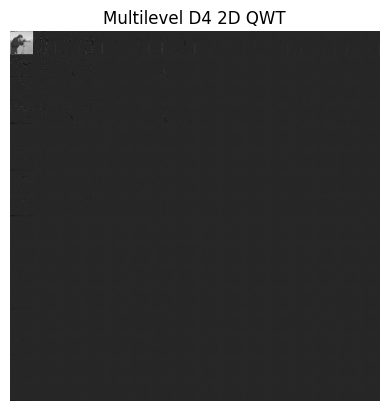

In [16]:
from src.multilevel_qwt import multilevel_d4_2d

img = pywt.data.camera()
matrix = np.array(img, dtype=float)

encode, n_qubits, spatial = QuantumImageEncoder.encode_grayscale(matrix)

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def circuit():
    qml.AmplitudeEmbedding(
        matrix.flatten()/np.linalg.norm(matrix.flatten()),
        wires=range(n_qubits),
        normalize=False
    )
    multilevel_d4_2d(range(n_qubits), spatial, levels=4)
    return qml.state()

state = circuit()

norm = np.linalg.norm(matrix.flatten())
coeffs = np.real(state) * norm

img_out = coeffs.reshape(matrix.shape)

plt.imshow(img_out, cmap='gray')
plt.title("Multilevel D4 2D QWT")
plt.axis('off')
plt.show()

Reconstruction is correct?: True


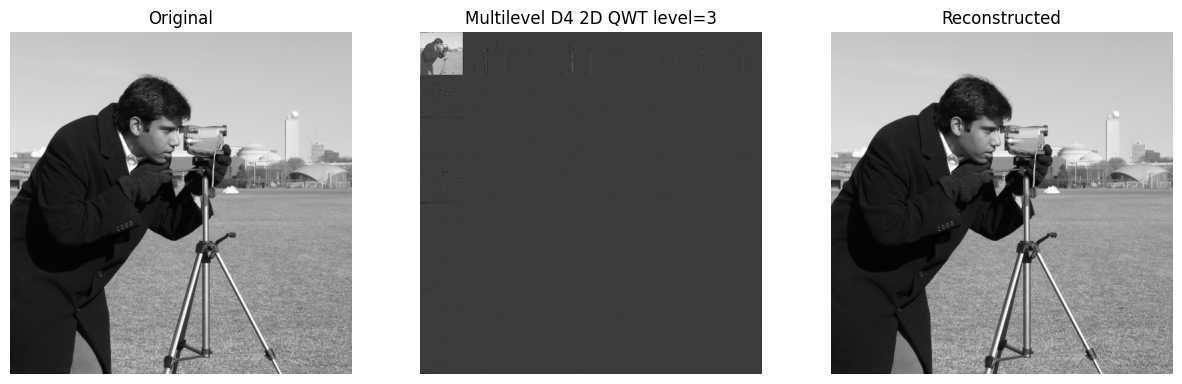

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml
import pywt.data

from src.encoding import QuantumImageEncoder
from src.multilevel_qwt import (
    multilevel_d4_2d,
    multilevel_d4_2d_inverse
)

# Load image
img = pywt.data.camera()
matrix = np.array(img, dtype=float)

encode, n_qubits, spatial = QuantumImageEncoder.encode_grayscale(matrix)

dev = qml.device("default.qubit", wires=n_qubits)

# 🔷 Forward circuit (D4)
@qml.qnode(dev)
def forward_circuit():
    qml.AmplitudeEmbedding(
        matrix.flatten()/np.linalg.norm(matrix.flatten()),
        wires=range(n_qubits),
        normalize=False
    )
    multilevel_d4_2d(range(n_qubits), spatial, levels=3)
    return qml.state()


# 🔷 Reconstruction circuit (D4)
@qml.qnode(dev)
def reconstruction_circuit():
    qml.AmplitudeEmbedding(
        matrix.flatten()/np.linalg.norm(matrix.flatten()),
        wires=range(n_qubits),
        normalize=False
    )
    multilevel_d4_2d(range(n_qubits), spatial, levels=3)
    multilevel_d4_2d_inverse(range(n_qubits), spatial, levels=3)
    return qml.state()


# Run circuits
transformed = forward_circuit()
reconstructed = reconstruction_circuit()


# Recover scaling
norm = np.linalg.norm(matrix.flatten())

transformed_img = np.real(transformed) * norm
reconstructed_img = np.real(reconstructed) * norm

transformed_img = transformed_img.reshape(matrix.shape)
reconstructed_img = reconstructed_img.reshape(matrix.shape)


# Reconstruction check
original = matrix.flatten()
reconstructed_vec = reconstructed_img.flatten()

print("Reconstruction is correct?:",
      np.allclose(original, reconstructed_vec, atol=1e-7))


# 🔷 Visualization
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(matrix, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(transformed_img, cmap='gray')
plt.title("Multilevel D4 2D QWT level=3")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(reconstructed_img, cmap='gray')
plt.title("Reconstructed")
plt.axis('off')

plt.show()

Reconstruction is correct?: True


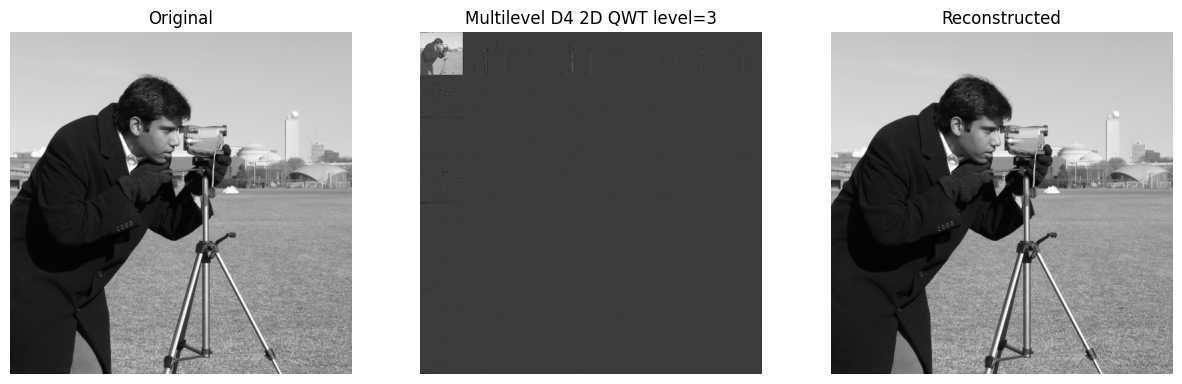

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml
import pywt.data

from src.encoding import QuantumImageEncoder
from src.multilevel_qwt import (
    multilevel_d4_2d,
    multilevel_d4_2d_inverse
)

# Load image
img = pywt.data.camera()
matrix = np.array(img, dtype=float)

encode, n_qubits, spatial = QuantumImageEncoder.encode_grayscale(matrix)

dev = qml.device("default.qubit", wires=n_qubits)

# 🔷 Forward circuit (D4)
@qml.qnode(dev)
def forward_circuit():
    qml.AmplitudeEmbedding(
        matrix.flatten()/np.linalg.norm(matrix.flatten()),
        wires=range(n_qubits),
        normalize=False
    )
    multilevel_d4_2d(range(n_qubits), spatial, levels=3)
    return qml.state()


# 🔷 Reconstruction circuit (D4)
@qml.qnode(dev)
def reconstruction_circuit():
    qml.AmplitudeEmbedding(
        matrix.flatten()/np.linalg.norm(matrix.flatten()),
        wires=range(n_qubits),
        normalize=False
    )
    multilevel_d4_2d(range(n_qubits), spatial, levels=3)
    multilevel_d4_2d_inverse(range(n_qubits), spatial, levels=3)
    return qml.state()


# Run circuits
transformed = forward_circuit()
reconstructed = reconstruction_circuit()


# Recover scaling
norm = np.linalg.norm(matrix.flatten())

transformed_img = np.real(transformed) * norm
reconstructed_img = np.real(reconstructed) * norm

transformed_img = transformed_img.reshape(matrix.shape)
reconstructed_img = reconstructed_img.reshape(matrix.shape)


# Reconstruction check
original = matrix.flatten()
reconstructed_vec = reconstructed_img.flatten()

print("Reconstruction is correct?:",
      np.allclose(original, reconstructed_vec, atol=1e-7))


# 🔷 Visualization
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(matrix, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(transformed_img, cmap='gray')
plt.title("Multilevel D4 2D QWT level=3")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(reconstructed_img, cmap='gray')
plt.title("Reconstructed")
plt.axis('off')

plt.show()